# 第 10 周 a｜EMR 数据清洗：从三张"脏"表重建分析队列

> **本周怎么学**：第 9 周已经学过主键、外键和 SQL 连接（`w09`）。本周先学这份精讲（手工清洗、逐步核对），再做 `w10b_reconstruction.ipynb`（工程实践：`primecvd/reconstruction.py` 把同样的规则写成带审查和测试的代码）。

**场景**：假设你刚加入一个研究组，医院信息科给了你三张从电子病历（EMR）系统导出的表。你的任务是把它们整理成**每人一行、可以直接做 Cox 分析**的数据集。

**这一节学什么**
- 多表**关联（merge）**：用病人 ID 把三张表连起来
- **长表 ↔ 宽表**转换（pivot）
- 统一五花八门的**诊断名称**和**检验项目名称**
- 处理**单位不一致**（HbA1c 的 % vs mmol/mol，身高的 cm vs 英尺英寸）
- 处理**缺失值**，并想清楚每个处理决定背后的假设
- 用"标准答案"（Data Asset 1）**验证**清洗结果。这一步在真实工作中几乎做不到，却是这份教学数据最宝贵的地方

**用到的数据**：Data Asset 2（三张 EMR 风格的表）

**前置**：第 1–6 周、第 9 周

> 💡 真实的医学数据科学项目里，**数据清洗通常占 60–80% 的时间**。这一节可能是四个笔记本里最"实用"的。

In [1]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())  # 向上找项目根目录
sys.path.insert(0, str(ROOT))

from primecvd import paths                 # 数据与输出路径（primecvd/paths.py）
from primecvd import pubplot as pp         # 顶刊风格作图工具箱（值得通读：primecvd/pubplot.py）
pp.setup()
pd.set_option("display.max_rows", 60)

## 1. 读入三张表

CSV 的第一列是没有名字的行号（pandas 会把它读成 `Unnamed: 0`）。用 `index_col=0` 把它当作行索引，就不会多出一列垃圾数据。

In [2]:
master = pd.read_csv(paths.EMR_MASTER, index_col=0)      # 主表：人口学信息 + 结局
diseases = pd.read_csv(paths.EMR_DISEASES, index_col=0)  # 慢病诊断表
measures = pd.read_csv(paths.EMR_MEASURES, index_col=0)  # 检验 / 测量表

for name, t in [("主表 master", master), ("诊断表 diseases", diseases), ("测量表 measures", measures)]:
    print(f"{name}: {t.shape[0]:,} 行 × {t.shape[1]} 列，{t['Patient_ID'].nunique():,} 个不同的病人")

主表 master: 50,000 行 × 6 列，50,000 个不同的病人
诊断表 diseases: 4,417 行 × 3 列，4,271 个不同的病人
测量表 measures: 210,000 行 × 5 列，50,000 个不同的病人


三张表的"形状"完全不同：
- **主表**：每人一行（5 万行 = 5 万人），这种叫**宽表**
- **诊断表**：只有**有诊断的人**才有记录，一个人可以有多行
- **测量表**：每个检验结果一行，每人 4–5 行，这种叫**长表**

我们的目标是把后两张表都变成"每人一行"，然后接到主表上。

## 2. 主表：初步检查

In [3]:
master.head(8)

,Patient_ID,Age_At_2024,SMOKING_STATUS,IRSD_Quintile,CVD_Event,CVD_Time
0,269,57.40,non,4,1,2019-12
1,272,46.23,ex,3,0,2022-12
2,281,62.49,non,5,0,2022-12
3,296,58.91,non,4,0,2022-12
4,317,54.09,ex,1,0,2022-12
5,344,63.54,non,5,0,2022-12
6,377,34.34,NaN,4,0,2022-12
7,416,50.10,non,5,0,2022-12


In [4]:
print("缺失值：")
print(master.isna().sum(), "\n")
print("吸烟状态（含缺失）：")
print(master["SMOKING_STATUS"].value_counts(dropna=False))

缺失值：
Patient_ID           0
Age_At_2024          0
SMOKING_STATUS    5727
IRSD_Quintile        0
CVD_Event            0
CVD_Time             0
dtype: int64 

吸烟状态（含缺失）：
SMOKING_STATUS
non        30845
ex          8361
NaN         5727
current     5067
Name: count, dtype: int64


In [5]:
print("CVD_Time 最常见的取值：")
print(master["CVD_Time"].value_counts().head(5), "\n")
print(master.groupby("CVD_Event")["CVD_Time"].agg(["min", "max", "nunique"]))

CVD_Time 最常见的取值：
CVD_Time
2022-12    47991
2017-02       52
2017-06       49
2018-10       48
2018-04       47
Name: count, dtype: int64 

               min      max  nunique
CVD_Event                           
0          2022-12  2022-12        1
1          2017-01  2023-01       72


**发现的问题**

| 问题 | 说明 | 后面怎么处理 |
|---|---|---|
| `Age_At_2024` | 给的是 **2024 年**的年龄，不是研究基线（2017 年 1 月）的年龄 | 减去 7 岁 |
| `SMOKING_STATUS` 缺失 5,727 人（11%） | EMR 里"没记录"很常见 | 第 5 节讨论 |
| `CVD_Time` 是"年-月"文本 | 不是随访年数，需要换算 | 第 5 节换算 |
| 所有未发生事件的人 `CVD_Time` 都是 2022-12 | 这是**数据提取截止日期**，每个人的真实失访时间已经丢失了 | 用它作为删失时间，并在验证时评估影响 |

## 3. 诊断表：统一诊断名称

In [6]:
diseases.head()

,Patient_ID,Category,Date
0,1338163469,Diabetes,2012-05
1,150591944,Diabetes,2014-12
2,545940569,ICD10: E11,2016-10
3,7134075944,Diabetes,2013-02
4,5959722392,Diabetes,2014-09


In [7]:
diseases["Category"].value_counts()

Category
Diabetes                  1491
T2DM                       800
ICD10: E11                 541
ICD9:250                   533
High glucose               186
High blood sugar           166
AF                         155
CKD                        151
Atrial fibrillation        112
Chronic kidney disease      88
ICD10: N18                  39
AFib                        33
A-fib                       31
Renal insufficiency         17
Chronic renal failure       17
ICD9: 427.31                15
CRF                         15
ICD10: I48                  14
ICD9: 585                   13
Name: count, dtype: int64

同一种病有很多种写法：自由文本（"Diabetes"、"High blood sugar"）、缩写（"T2DM"、"AFib"）、ICD-10 编码（"E11"）、ICD-9 编码（"250"）……这是真实 EMR 最典型的问题。

做法：写一个**映射字典**，把每种写法对应到标准名称。映射表一定要**完整列出、人工审核**，这是整个清洗流程里最需要医学知识的一步。

| 标准名称 | 原始写法 | 说明 |
|---|---|---|
| diabetes | Diabetes, T2DM, ICD10: E11, ICD9:250, High glucose, High blood sugar | E11 = 2 型糖尿病 |
| CKD | CKD, Chronic kidney disease, ICD10: N18, ICD9: 585, Renal insufficiency, Chronic renal failure, CRF | N18 = 慢性肾病 |
| AF | AF, Atrial fibrillation, AFib, A-fib, ICD10: I48, ICD9: 427.31 | I48 = 房颤 |

⚠️ "High glucose"、"High blood sugar" 在真实世界里**不一定**等于糖尿病诊断（可能只是一次血糖偏高）。这里按数据作者的设定把它们当作糖尿病，但在真实研究中，这类决定需要和临床医生讨论，并写进研究方案。

In [8]:
DIAGNOSIS_MAP = {
    # 糖尿病
    "Diabetes": "diabetes", "T2DM": "diabetes", "ICD10: E11": "diabetes", "ICD9:250": "diabetes",
    "High glucose": "diabetes", "High blood sugar": "diabetes",
    # 慢性肾病
    "CKD": "CKD", "Chronic kidney disease": "CKD", "ICD10: N18": "CKD", "ICD9: 585": "CKD",
    "Renal insufficiency": "CKD", "Chronic renal failure": "CKD", "CRF": "CKD",
    # 房颤
    "AF": "AF", "Atrial fibrillation": "AF", "AFib": "AF", "A-fib": "AF",
    "ICD10: I48": "AF", "ICD9: 427.31": "AF",
}

diseases["condition"] = diseases["Category"].map(DIAGNOSIS_MAP)

# 检查：有没有漏掉没映射的写法？（map 找不到时会返回 NaN）
unmapped = diseases.loc[diseases["condition"].isna(), "Category"].unique()
print("没有映射到的写法：", unmapped)
assert len(unmapped) == 0, "有诊断名称没有被映射，请补充 DIAGNOSIS_MAP"

diseases["condition"].value_counts()

没有映射到的写法： []


condition
diabetes    3717
AF           360
CKD          340
Name: count, dtype: int64

`assert` 是一个"安全检查"：条件不成立时程序会立刻报错停下。以后数据更新、冒出新写法时，你会马上知道，而不是悄悄漏掉一批病人。

诊断日期都在 2012–2016 年，全部早于研究基线（2017-01），所以它们都是**基线时已存在的疾病**。

In [9]:
print("诊断日期范围：", diseases["Date"].min(), "到", diseases["Date"].max())

诊断日期范围： 2012-01 到 2016-12


### 长表 → 宽表

现在每个诊断是一行。用 `pd.crosstab` 数一数每个病人每种病有几条记录，再转成 0/1：

In [10]:
dx_wide = (pd.crosstab(diseases["Patient_ID"], diseases["condition"]) > 0).astype(int)
print(dx_wide.shape)
dx_wide.head()

(4271, 3)


condition,AF,CKD,diabetes
Patient_ID,,,
569,0,1,0
6617,0,0,1
6896,1,0,1
8381,0,0,1
10712,0,0,1


只有 4,271 个病人有诊断记录。其余约 4.6 万人没有出现在这张表里，意思是"**没有记录到**这些病"。合并时要把他们的值补成 0（第 6 节）。

## 4. 测量表：统一检验名称、数值和单位

In [11]:
measures.head(10)

,Patient_ID,Value,Description,Date,Unit
0,819127997,78.08730821809296,eGFR,2014-03,mL/min/1.73m²
1,3847713176,8.369465931621287,HbA1c,2015-02,%
2,3508304696,140.32800536506784,SBP,2016-09,mmHg
3,1685212472,69.9920201360966,GFR,2015-06,mL/min/1.73m²
4,1105805072,29.95,BMI,2015-04,NaN
5,3049003469,24.87,BMI,2016-06,NaN
6,196635917,135.2374007644571,SBP,2015-03,mmHg
7,3250981952,25.68,BMI,2016-07,NaN
8,4785131801,27.7,BMI,2015-12,NaN
9,1725409241,123.7877015577343,SBP,2016-01,mmHg


In [12]:
print("Value 列的数据类型：", measures["Value"].dtype)
print("不同的 Description 写法有", measures["Description"].nunique(), "种：")
measures["Description"].value_counts()

Value 列的数据类型： object
不同的 Description 写法有 35 种：


Description
BMI                          40000
eGFR                         30239
HbA1c                        27600
SBP                          24806
EGFR                         10181
Weight                       10000
Height                       10000
Systolic BP                   9991
HBA1C                         7510
A1C                           5001
Systolic Blood Pressure       4982
BP Systolic                   4020
eGFR (mL/min/1.73m²)          4017
GFR                           2547
Hb A1c                        2506
LOINC: 4548-4                 1904
Blood Pressure – Systolic     1557
HbA1c mmol/mol                1531
Estimated GFR                 1504
Glycated hemoglobin           1236
Glycosylated hemoglobin       1203
SBP (mmHg)                    1042
BP SYS                         896
BP_sys                         863
BP_Systolic                    818
HA1C                           759
HbAlc                          750
GFR-e                          510
e-GFR   

问题一大堆：
1. **`Value` 是文本类型**（`object`），说明里面混着非数字的内容
2. **同一个检验有很多种写法**（总共 35 种）：光 HbA1c 就有 10 种，比如 "HBA1C"、"A1C"、"HbAlc"（字母 l 不是数字 1！）、"LOINC: 4548-4"（LOINC 是国际通用的检验编码）……
3. **单位不统一**

一步一步来。

### 4.1 统一检验名称

35 种写法都写进映射字典也可以，但会很长。这里换一种思路：先把文本"标准化"（转小写、去掉空格和符号），再用**关键词规则**判断。

In [13]:
def standardize_measure(description):
    """把各种检验名称归到标准名称：HbA1c / eGFR / SBP / BMI / Height / Weight"""
    d = re.sub(r"[^a-z0-9]", "", description.lower())   # 只保留小写字母和数字
    if "gfr" in d:
        return "eGFR"
    if any(k in d for k in ["a1c", "alc", "hemoglobin", "45484"]):
        return "HbA1c"
    if any(k in d for k in ["sbp", "sybp", "sys"]):
        return "SBP"
    if d in ("bmi", "height", "weight"):
        return {"bmi": "BMI", "height": "Height", "weight": "Weight"}[d]
    return None                                           # 规则没覆盖到的写法


measures["measure"] = measures["Description"].map(standardize_measure)

# 最关键的一步：把"原始写法 → 标准名称"的对应表完整打印出来，人工逐行检查
mapping_check = measures.groupby(["measure", "Description"], dropna=False).size().rename("行数")
mapping_check

measure  Description              
BMI      BMI                          40000
HbA1c    A1C                           5001
         Glycated hemoglobin           1236
         Glycosylated hemoglobin       1203
         HA1C                           759
         HBA1C                         7510
         Hb A1c                        2506
         HbA1c                        27600
         HbA1c mmol/mol                1531
         HbAlc                          750
         LOINC: 4548-4                 1904
Height   Height                       10000
SBP      BP SYS                         896
         BP Systolic                   4020
         BP_Systolic                    818
         BP_sys                         863
         Blood Pressure – Systolic     1557
         SBP                          24806
         SBP (mmHg)                    1042
         SyBP                           328
         Syst BP                        327
         Systolic BP                   99

In [14]:
assert measures["measure"].notna().all(), "有检验名称没有被识别，请检查规则"
measures["measure"].value_counts()

measure
eGFR      50000
HbA1c     50000
SBP       50000
BMI       40000
Weight    10000
Height    10000
Name: count, dtype: int64

⚠️ **规则很方便，但也危险**。比如 `"sys"` 这个关键词，如果以后出现 "Diastolic / systolic ratio"，也会被误判成 SBP。所以**打印对应表、人工检查**这一步绝对不能省。

### 4.2 把 Value 转成数字

`pd.to_numeric(..., errors="coerce")` 能转成数字的就转，转不了的变成 `NaN`。先看看哪些值转不了：

In [15]:
measures["value_num"] = pd.to_numeric(measures["Value"], errors="coerce")

bad = measures[measures["value_num"].isna()]
print(f"转换失败的有 {len(bad):,} 行，它们的 measure 和 Unit：")
print(bad.groupby(["measure", "Unit"]).size(), "\n")
print("例子：", bad["Value"].head(8).tolist())

转换失败的有 1,000 行，它们的 measure 和 Unit：
measure  Unit         
Height   feet-and-inch    1000
dtype: int64 

例子： ['5\'12"', '5\'3"', '5\'9"', '5\'4"', '5\'1"', '5\'5"', '5\'8"', '5\'7"']


转不了的全部是**用英尺英寸记录的身高**，比如 `5'7"` 表示 5 英尺 7 英寸。写一个函数换算成厘米（1 英尺 = 12 英寸，1 英寸 = 2.54 厘米）：

In [16]:
def feet_inches_to_cm(text):
    """把 5'7" 这样的英制身高换算成厘米"""
    match = re.fullmatch(r"(\d+)'(\d+)\"", text.strip())
    if match is None:
        return np.nan
    feet, inches = int(match.group(1)), int(match.group(2))
    return (feet * 12 + inches) * 2.54


print(feet_inches_to_cm("5'7\""), feet_inches_to_cm("6'0\""), feet_inches_to_cm("5'12\""))

170.18 182.88 182.88


注意数据里有 `5'12"` 这种写法。12 英寸应该进位成 6 英尺，这是原始数据生成时四舍五入留下的"瑕疵"。函数照样能正确换算（5×12 + 12 = 72 英寸 = 6 英尺），但它提醒我们：**真实数据里什么怪写法都可能出现，解析函数要足够稳健**。

In [17]:
is_imperial = measures["Unit"] == "feet-and-inch"
measures.loc[is_imperial, "value_num"] = measures.loc[is_imperial, "Value"].map(feet_inches_to_cm)
measures.loc[is_imperial, "Unit"] = "cm"

print("仍然无法转换的行数：", measures["value_num"].isna().sum())

仍然无法转换的行数： 0


### 4.3 统一单位：HbA1c

HbA1c 有两种国际通用的单位：
- **%**（NGSP 单位，美国、澳洲以前常用）
- **mmol/mol**（IFCC 单位，现在国际推荐）

换算公式：**% = mmol/mol ÷ 10.929 + 2.15**

先按单位看看数值分布，确认单位列靠不靠谱：

In [18]:
hba1c = measures[measures["measure"] == "HbA1c"]
hba1c.groupby("Unit")["value_num"].describe()

,count,mean,std,min,25%,50%,75%,max
Unit,,,,,,,,
%,47500.0,4.787117,0.935530,2.233112,4.234816,4.656433,5.118093,12.707635
mmol/mol,2500.0,28.521893,9.629153,2.742582,22.877636,27.253490,32.428550,85.610520


两组的分布差别很大（% 的中位数约 4.7，mmol/mol 的中位数约 27），说明单位列基本可信。

但要注意，两组的范围**并非完全不重叠**：mmol/mol 组的最小值只有 2.7，落进了 % 的范围。它对应的是原始值约 2.4% 的 HbA1c，这在生理上几乎不可能，属于合成数据的特点。这提醒我们：**只靠数值大小去"猜"单位并不可靠，有单位列时要以单位列为准。**

⚠️ **一个陷阱**：有一种检验名称叫 `"HbA1c mmol/mol"`，但它的大部分记录单位列写的是 **%**，数值也在 % 的范围里。**名称里的单位不可信，要以单位列和实际数值为准。**

In [19]:
hba1c[hba1c["Description"] == "HbA1c mmol/mol"].groupby("Unit")["value_num"].describe()[["count", "min", "max"]]

,count,min,max
Unit,,,
%,1456.0,2.433908,10.311068
mmol/mol,75.0,10.746050,64.961483


In [20]:
is_ifcc = (measures["measure"] == "HbA1c") & (measures["Unit"] == "mmol/mol")
measures.loc[is_ifcc, "value_num"] = measures.loc[is_ifcc, "value_num"] / 10.929 + 2.15
measures.loc[is_ifcc, "Unit"] = "%"

# 换算后再检查一次：所有 HbA1c 都应该在 % 的范围内
measures.loc[measures["measure"] == "HbA1c"].groupby("Unit")["value_num"].describe()

,count,mean,std,min,25%,50%,75%,max
Unit,,,,,,,,
%,50000.0,4.785748,0.932893,2.233112,4.235419,4.655732,5.118048,12.707635


### 4.4 每人每项检验只能留一个值

真实 EMR 里，一个人可能测过很多次血压。常见规则是"**取基线前最近的一次**"。先检查这份数据里有没有重复：

In [21]:
dup = measures.duplicated(subset=["Patient_ID", "measure"]).sum()
print("同一个人同一项检验出现多次的记录数：", dup)

同一个人同一项检验出现多次的记录数： 0


这份数据每人每项只有一条记录，比真实情况简单。不过下面的代码仍然按"**按日期排序，取最后一次**"来写，这是通用的好习惯：数据换成真实 EMR 时，代码不用改。

### 4.5 长表 → 宽表，并计算 BMI

In [22]:
meas_wide = (
    measures.sort_values("Date")
    .pivot_table(index="Patient_ID", columns="measure", values="value_num", aggfunc="last")
)
print(meas_wide.shape)
print("各列缺失数：")
print(meas_wide.isna().sum())

(50000, 6)
各列缺失数：
measure
BMI       10000
HbA1c         0
Height    40000
SBP           0
Weight    40000
eGFR          0
dtype: int64


BMI 缺失了 1 万人：这些人没有直接记录 BMI，但记录了**身高和体重**，可以自己算：**BMI = 体重(kg) ÷ 身高(m)²**

In [23]:
bmi_calc = meas_wide["Weight"] / (meas_wide["Height"] / 100) ** 2
meas_wide["BMI_source"] = np.where(meas_wide["BMI"].notna(), "直接记录", "身高体重计算")
meas_wide["BMI"] = meas_wide["BMI"].fillna(bmi_calc)

print("BMI 仍缺失：", meas_wide["BMI"].isna().sum())
meas_wide["BMI_source"].value_counts()

BMI 仍缺失： 0


BMI_source
直接记录      40000
身高体重计算    10000
Name: count, dtype: int64

## 5. 主表：年龄、吸烟、随访时间

### 5.1 年龄

研究基线是 2017 年 1 月，主表给的是 2024 年的年龄，所以 **基线年龄 = Age_At_2024 − 7**。

### 5.2 吸烟状态缺失怎么办？

有 11% 的人没有吸烟记录。几种常见做法：

| 做法 | 隐含的假设 | 优缺点 |
|---|---|---|
| 删掉这些人（完整病例分析） | 缺失完全随机 | 简单，但损失样本，而且可能有偏 |
| 当作"从不吸烟" | 医生只在病人吸烟时才会记录 | EMR 里常见的真实情况，但无法验证 |
| **单独设一个"未知"类别** | 不做额外假设 | ✅ 透明，这里采用这种做法 |
| 多重插补 | 缺失可以由其他变量预测 | 最严谨，但比较复杂 |

我们先设成 `"unknown"`，第 7 节验证时再看看真相。

### 5.3 随访时间

- 基线：2017-01-01
- 发生事件的人：随访到 `CVD_Time` 那个月。只知道月份，就取**月中（15 号）**作为近似
- 没发生事件的人：统一删失在 2022-12（数据截止日期），同样取月中

⚠️ **这是一个故意保留的反例。** 用统一的截止月份构造删失时间，会系统性地高估随访时间，第 7.2 节会量化这个偏差。所以工程篇的重建模块（w10b）**不输出**可以冒充原始随访的 `cvd_time`，只保留一个明确标为"非原始"的粗化时间。

In [24]:
BASELINE = pd.Timestamp("2017-01-01")

cohort_master = pd.DataFrame({
    "Patient_ID": master["Patient_ID"],
    "IRSD_quintile": master["IRSD_Quintile"],
    "Age": master["Age_At_2024"] - 7,
    "smoking_status": master["SMOKING_STATUS"].fillna("unknown"),
    "cvd_event": master["CVD_Event"],
})
end_date = pd.to_datetime(master["CVD_Time"], format="%Y-%m") + pd.Timedelta(days=14)
cohort_master["cvd_time"] = (end_date - BASELINE).dt.days / 365.25

cohort_master.head()

,Patient_ID,IRSD_quintile,Age,smoking_status,cvd_event,cvd_time
0,269,4,50.40,non,1,2.951403
1,272,3,39.23,ex,0,5.952088
2,281,5,55.49,non,0,5.952088
3,296,4,51.91,non,0,5.952088
4,317,1,47.09,ex,0,5.952088


## 6. 合并三张表

用 `merge` 以 `Patient_ID` 为键把表连起来。`how="left"` 表示**以主表为准**：主表里的每个人都保留，另一张表里找不到的就填 `NaN`。

In [25]:
cohort = (
    cohort_master
    .merge(dx_wide, left_on="Patient_ID", right_index=True, how="left")
    .merge(meas_wide[["BMI", "HbA1c", "eGFR", "SBP"]], left_on="Patient_ID", right_index=True, how="left")
)

# 诊断表里没有记录 → 视为没有这种病（这也是一个假设！）
for col in ["diabetes", "CKD", "AF"]:
    cohort[col] = cohort[col].fillna(0).astype(int)

# 合并后的安全检查
assert len(cohort) == len(master), "合并后行数变了，可能有重复的 ID"
assert cohort["Patient_ID"].is_unique
print("合并后：", cohort.shape)
print("缺失值：", cohort.isna().sum().sum())

# 按 Data Asset 1 的列顺序排列
cols = ["Patient_ID", "IRSD_quintile", "Age", "smoking_status", "BMI", "diabetes", "CKD",
        "HbA1c", "eGFR", "SBP", "AF", "cvd_event", "cvd_time"]
cohort = cohort[cols]
cohort.head()

合并后： (50000, 13)
缺失值： 0


,Patient_ID,IRSD_quintile,Age,smoking_status,BMI,diabetes,CKD,HbA1c,eGFR,SBP,AF,cvd_event,cvd_time
0,269,4,50.40,non,28.194773,0,0,4.317890,83.077560,118.668194,0,1,2.951403
1,272,3,39.23,ex,16.818800,0,0,4.700951,81.488401,123.719732,0,0,5.952088
2,281,5,55.49,non,23.520000,0,0,3.669685,86.779230,126.650517,0,0,5.952088
3,296,4,51.91,non,31.980000,0,0,4.486977,94.704093,113.889670,0,0,5.952088
4,317,1,47.09,ex,25.350000,0,0,4.315440,86.336256,125.912615,0,0,5.952088


In [26]:
paths.PROCESSED.mkdir(parents=True, exist_ok=True)
out_path = paths.PROCESSED / "cohort_from_emr.csv"
cohort.to_csv(out_path, index=False)
print("已保存：", out_path)

已保存： data/processed/cohort_from_emr.csv


🎉 我们从三张乱七八糟的表，得到了一张每人一行、没有缺失、可以直接分析的表。

**但它对不对？** 真实工作中，这个问题通常只能靠抽查病历来部分回答。PRIME-CVD 的好处是：Data Asset 2 是由 Data Asset 1 "弄脏"得来的，**我们有标准答案**。

## 7. 验证：和 Data Asset 1 对比

从数据作者公开的派生代码可以知道，主表的行顺序和 Data Asset 1 完全一致，所以可以**按行一一对齐**比较。

In [27]:
truth = pd.read_csv(paths.ASSET1)
assert len(truth) == len(cohort)

rows = []
for col in ["Age", "BMI", "HbA1c", "eGFR", "SBP"]:
    diff = (cohort[col].values - truth[col].values)
    rows.append({"变量": col, "类型": "连续", "最大绝对误差": np.abs(diff).max(),
                 "平均绝对误差": np.abs(diff).mean(), "一致率": np.nan})
for col in ["IRSD_quintile", "diabetes", "CKD", "AF", "cvd_event"]:
    rows.append({"变量": col, "类型": "分类", "最大绝对误差": np.nan, "平均绝对误差": np.nan,
                 "一致率": (cohort[col].values == truth[col].values).mean()})
validation = pd.DataFrame(rows).set_index("变量")
validation.style.format({"最大绝对误差": "{:.4f}", "平均绝对误差": "{:.4f}", "一致率": "{:.2%}"}, na_rep="—")

,类型,最大绝对误差,平均绝对误差,一致率
变量,,,,
Age,连续,0.0050,0.0025,—
BMI,连续,0.6300,0.0086,—
HbA1c,连续,0.0000,0.0000,—
eGFR,连续,0.0000,0.0000,—
SBP,连续,0.0000,0.0000,—
IRSD_quintile,分类,—,—,100.00%
diabetes,分类,—,—,100.00%
CKD,分类,—,—,100.00%
AF,分类,—,—,100.00%


**解读**
- 分类变量（诊断、IRSD、结局）**100% 一致**：诊断名称的映射完全正确
- HbA1c、eGFR、SBP 的误差是 0 或接近 0：单位换算正确
- 年龄误差 < 0.005 岁：主表里的年龄四舍五入到了 2 位小数
- **BMI 有小误差**：来自 20% 用身高体重计算 BMI 的人，身高和体重都四舍五入到 1 位小数，英制身高更是只精确到整英寸（≈ 2.5 cm）

看看 BMI 误差来自哪里：

In [28]:
bmi_err = (cohort["BMI"].values - truth["BMI"].values)
source = meas_wide.loc[cohort["Patient_ID"], "BMI_source"].values
pd.Series(np.abs(bmi_err)).groupby(source).describe()[["count", "mean", "max"]]

,count,mean,max
直接记录,40000.0,0.002488,0.005000
身高体重计算,10000.0,0.032899,0.630001


### 7.1 吸烟状态的真相

In [29]:
pd.crosstab(cohort["smoking_status"], truth["smoking_status"],
            rownames=["我们重建的"], colnames=["真实值"])

真实值,current,ex,non
我们重建的,,,
current,5067,0,0
ex,0,8361,0
non,0,0,30845
unknown,0,0,5727


**所有"未知"的人其实都是从不吸烟者！** 数据作者模拟的正是 EMR 里常见的一种现象：医生往往只在病人吸烟时才会特意记录。

在真实数据里我们永远看不到这张表。这提醒我们：**缺失值往往不是随机的**，缺失本身就携带着信息。

### 7.2 随访时间

In [30]:
time_err = cohort["cvd_time"].values - truth["cvd_time"].values
pd.Series(time_err).groupby(truth["cvd_event"].map({0: "删失（未发生事件）", 1: "发生事件"})) \
    .describe()[["count", "mean", "std", "min", "max"]]

,count,mean,std,min,max
cvd_event,,,,,
删失（未发生事件）,47991.0,1.051268,0.542538,-1.355126,3.274299
发生事件,2009.0,-0.003233,0.024008,-0.046537,0.038292


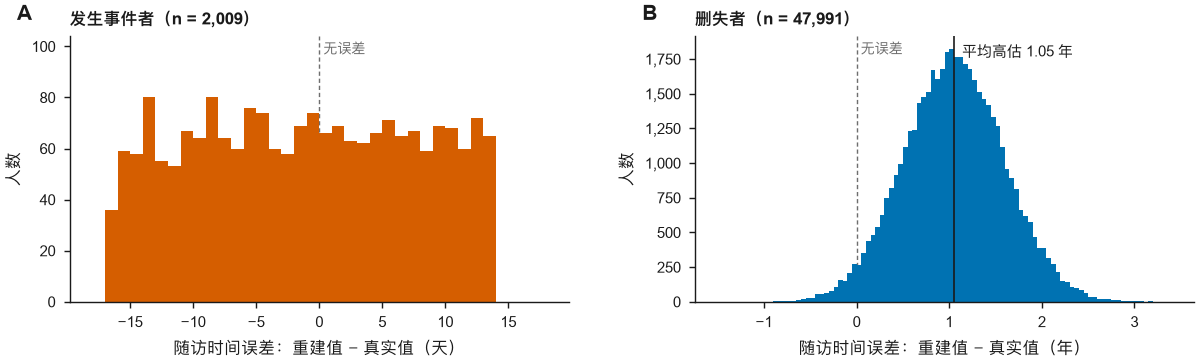

In [31]:
fig, axes = plt.subplots(1, 2, figsize=pp.size(pp.DOUBLE, 58))
is_event = truth["cvd_event"].values == 1

# A：发生事件者。误差只有十几天，用"天"做单位，数字才直观
ax = axes[0]
counts, _, _ = ax.hist(time_err[is_event] * 365.25, bins=np.arange(-18, 18.5, 1), color=pp.EXPOSED, lw=0)
ax.set_ylim(0, counts.max() * 1.3)
ax.set_xticks([-15, -10, -5, 0, 5, 10, 15])
ax.set_xlabel("随访时间误差：重建值 − 真实值（天）")
ax.set_title(f"发生事件者（n = {is_event.sum():,}）", fontsize=7)

# B：删失者。误差以年计，并标出平均偏差
ax = axes[1]
ax.hist(time_err[~is_event], bins=np.arange(-1.5, 3.45, 0.05), color=pp.REFERENCE, lw=0)
mean_err = time_err[~is_event].mean()
ax.axvline(mean_err, color=pp.INK, lw=0.7)
ax.text(mean_err, 0.97, f"  平均高估 {mean_err:.2f} 年", transform=ax.get_xaxis_transform(),
        fontsize=6.3, va="top")
ax.set_xlabel("随访时间误差：重建值 − 真实值（年）")
ax.set_title(f"删失者（n = {(~is_event).sum():,}）", fontsize=7)

for ax, letter in zip(axes, "AB"):
    pp.ref_line(ax, 0, label="无误差", label_pos=0.98)
    ax.set_ylabel("人数")
    pp.thousands_axis(ax)
    pp.panel_label(ax, letter)
fig.tight_layout(w_pad=3)
pp.save(fig, "04_followup_time_error")
plt.show()

- **发生事件的人**（图 A）：误差在 −17 到 +14 天之间，因为我们只知道事件发生在哪个月，统一取了 15 号
- **删失的人**：误差很大，**平均高估约 1 年**（最多高估 3.3 年）。EMR 把所有人都截止到 2022-12，但真实情况是很多人更早就失访了（搬家、换医院……）。少数人的误差是负的，因为他们的真实随访时间比 2022-12 还长

这是 EMR 研究的一个经典陷阱：**"没有记录到事件"不等于"一直被观察而没有发生事件"**。

🎨 **设计要点**
- **两个面板用不同的单位**（天 vs 年）：误差的量级差了约 25 倍，各自选最自然的单位，并在轴标题里写清楚
- **颜色语义和前面一致**：事件朱红、删失蓝
- **"无误差"参考线**（x = 0）和**平均误差线**让偏差的方向和大小一目了然

> **图 9｜EMR 重建的随访时间与真实值之差。** A 为发生事件者（单位：天），B 为删失者（单位：年）。虚线为零误差，B 中实线为平均误差。

### 7.3 最终检验：两份数据的 Cox 模型结果一致吗？

用第 6 周 a 的同一个模型，分别在"真实数据"和"我们重建的数据"上拟合，比较 HR。吸烟状态的"未知"组单独作为一类放进模型。

In [32]:
def make_design(data):
    """与第 6 周 a 相同的变量设置，另外加入吸烟状态"未知"组"""
    X = pd.DataFrame(index=data.index)
    X["age_10"] = data["Age"] / 10
    X["bmi_5"] = data["BMI"] / 5
    X["sbp_10"] = data["SBP"] / 10
    X["egfr_10"] = data["eGFR"] / 10
    X["hba1c"] = data["HbA1c"]
    for col in ["diabetes", "CKD", "AF"]:
        X[col] = data[col]
    for level in ["ex", "current", "unknown"]:
        X[f"smoke_{level}"] = (data["smoking_status"] == level).astype(int)
    for q in [1, 2, 3, 4]:
        X[f"irsd_{q}"] = (data["IRSD_quintile"] == q).astype(int)
    X["cvd_time"], X["cvd_event"] = data["cvd_time"], data["cvd_event"]
    # 某一类没有任何人（比如真实数据里没有"未知"吸烟）时，去掉这一列
    return X.loc[:, X.nunique() > 1]


LABELS = {
    "age_10": "年龄（每 10 岁）", "bmi_5": "BMI（每 5 kg/m²）", "sbp_10": "收缩压（每 10 mmHg）",
    "egfr_10": "eGFR（每 10 单位）", "hba1c": "HbA1c（每 1%）", "diabetes": "糖尿病",
    "CKD": "慢性肾病", "AF": "房颤", "smoke_ex": "已戒烟 vs 从不", "smoke_current": "现在吸烟 vs 从不",
    "smoke_unknown": "吸烟未知 vs 从不", "irsd_1": "IRSD 1 最贫困 vs 5", "irsd_2": "IRSD 2 vs 5",
    "irsd_3": "IRSD 3 vs 5", "irsd_4": "IRSD 4 vs 5",
}


def fit_hr(data):
    """拟合 Cox 模型，返回 'HR (95% CI)' 文本和 C 指数"""
    cph = CoxPHFitter().fit(make_design(data), duration_col="cvd_time", event_col="cvd_event",
                            fit_options={"step_size": 0.5})
    s = cph.summary
    hr = s.apply(lambda r: f"{r['exp(coef)']:.2f} ({r['exp(coef) lower 95%']:.2f}–{r['exp(coef) upper 95%']:.2f})",
                 axis=1)
    return hr, cph.concordance_index_


hr_truth, c_truth = fit_hr(truth)
hr_emr, c_emr = fit_hr(cohort)
comparison = pd.DataFrame({"真实数据 (Data Asset 1)": hr_truth, "EMR 重建数据": hr_emr}).fillna("—")
comparison = comparison.loc[[k for k in LABELS if k in comparison.index]]   # 按 LABELS 顺序排列
comparison.index = [LABELS[k] for k in comparison.index]
comparison.loc["C 指数"] = [f"{c_truth:.3f}", f"{c_emr:.3f}"]
paths.save_table(comparison, "04_cox_truth_vs_emr")
comparison

,真实数据 (Data Asset 1),EMR 重建数据
年龄（每 10 岁）,1.96 (1.88–2.04),1.96 (1.88–2.05)
BMI（每 5 kg/m²）,1.11 (1.06–1.17),1.12 (1.06–1.17)
收缩压（每 10 mmHg）,1.09 (1.06–1.12),1.09 (1.05–1.12)
eGFR（每 10 单位）,0.87 (0.80–0.95),0.88 (0.80–0.95)
HbA1c（每 1%）,1.39 (1.33–1.46),1.39 (1.34–1.46)
糖尿病,5.35 (4.58–6.25),5.35 (4.58–6.24)
慢性肾病,0.86 (0.59–1.25),0.87 (0.60–1.27)
房颤,4.02 (3.11–5.21),3.94 (3.03–5.11)
已戒烟 vs 从不,1.46 (1.30–1.62),1.43 (1.28–1.59)
现在吸烟 vs 从不,1.58 (1.38–1.81),1.55 (1.35–1.77)


**解读**
- 所有 HR 都非常接近（大多数完全相同或只差 0.01），C 指数 0.876 vs 0.875，说明清洗流程正确
- 吸烟"未知"组的 HR = 0.89，置信区间跨过 1：它其实就是一群"从不吸烟者"，所以和参照组（从不吸烟）没有显著差别。在真实数据里，这个结果就是一条线索，暗示"未知"的人可能大多不吸烟
- 由于删失者的随访时间被系统性高估，总人年变多了，基线风险会被低估；不过 HR 是**相对**指标，受到的影响较小

🎯 **这就是 PRIME-CVD 最独特的教学价值**：你可以亲眼看到每个清洗决定对最终结论的影响。

## 小结：EMR 数据清洗检查清单

1. ☐ 读入后先看**形状、类型、缺失**，确认每张表是长表还是宽表
2. ☐ **诊断名称 / 编码**：建映射表，`assert` 没有遗漏，映射表交给临床专家审核
3. ☐ **检验名称**：规则或字典都行，但一定要**打印对应表人工检查**
4. ☐ **数值类型**：文本转数字，逐一检查转换失败的记录
5. ☐ **单位**：按单位分组看分布，统一换算后**再检查一次**
6. ☐ **重复记录**：定好规则（比如基线前最近一次）
7. ☐ **缺失值**：每种处理方式都是一个**假设**，写下来
8. ☐ **合并**：`how="left"` + 检查行数不变、ID 不重复
9. ☐ **时间变量**：想清楚"随访结束"在数据里到底意味着什么
10. ☐ 保存清洗后的数据到 `data/processed/`，**永远不要改原始数据**

## 练习

1. 如果把吸烟"未知"当作"从不吸烟"（`fillna("non")`），重新跑第 7.3 节。HR 是不是更接近真实数据了？在真实世界里，你能事先知道这样做是对的吗？
2. 如果完全删掉吸烟状态缺失的人（完整病例分析），Cox 结果会怎样变化？
3. 找出诊断表里有**两种及以上**慢病的病人（提示：`dx_wide.sum(axis=1) >= 2`），有多少人？
4. （进阶）PRIME-CVD 论文作业 1：从诊断表中分别找出"只有 CKD"和"只有 2 型糖尿病"的两组人（互斥），比较他们的 IRSD 分布，画成图。